# CNN Project — MNIST Handwritten Digit Classification

**Dataset:** [MNIST](http://yann.lecun.com/exdb/mnist/) — 70,000 greyscale images of handwritten digits (0–9)  
**Objective:** Design and train a custom CNN to classify handwritten digits with high accuracy.  
**Train/Val/Test Split:** 60,000 train / 10,000 test 
**Framework:** PyTorch  


## 1. Import Libraries

In [1]:
#  Standard & third-party 
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns

#  PyTorch 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR

#  TorchVision 
import torchvision
from torchvision import datasets, transforms

# ── Sklearn metrics 
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

#  Model summary 
from torchsummary import summary

# ── Reproducibility 
torch.manual_seed(42)
np.random.seed(42)

# ── Device 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


## 2. Load and Explore Dataset
 
- **60,000** training images, **10,000** test images  
- Each image is **28 × 28 pixels**, single-channel greyscale  
- 10 classes: digits **0 through 9**

We apply an **80/20 split** 

In [2]:
#  Hyperparameters 
IMG_SIZE      = 28       # MNIST native resolution
BATCH_SIZE    = 64       # mini-batch size
LEARNING_RATE = 1e-3     # initial LR for Adam
MIN_LR        = 1e-5     # CosineAnnealing floor
EPOCHS        = 20       # total training epochs
VAL_SPLIT     = 0.20     # fraction of train reserved for validation
NUM_CLASSES   = 10       # digits 0-9
CLASS_NAMES   = [str(i) for i in range(NUM_CLASSES)]

#  MNIST mean / std (computed over training set) 
MNIST_MEAN = (0.1307,)
MNIST_STD  = (0.3081,)

print(f"Classes : {CLASS_NAMES}")
print(f"Device  : {device}")

Classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Device  : cuda


In [3]:
#  Transforms 
# Training: mild augmentation to improve generalisation
train_transform = transforms.Compose([
    transforms.RandomRotation(10),                    
    transforms.RandomAffine(0, translate=(0.1, 0.1)), # small translation
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

# Validation 
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

print("Train transform:", train_transform)
print()
print("Val/Test transform:", val_transform)

Train transform: Compose(
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)

Val/Test transform: Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)


In [4]:
#  Download dataset 
full_train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=val_transform
)

print(f"Full training samples : {len(full_train_dataset)}")
print(f"Test samples          : {len(test_dataset)}")

#  80 / 20 train-validation split 
val_size   = int(VAL_SPLIT * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # reproducible
)

# Override val transform 
val_dataset.dataset = datasets.MNIST(
    root='./data', train=True, download=False, transform=val_transform
)

print(f"Train samples         : {len(train_dataset)}")
print(f"Validation samples    : {len(val_dataset)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.65MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]

Full training samples : 60000
Test samples          : 10000
Train samples         : 48000
Validation samples    : 12000


In [5]:
#  DataLoaders 
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 750
Val batches   : 188
Test batches  : 157


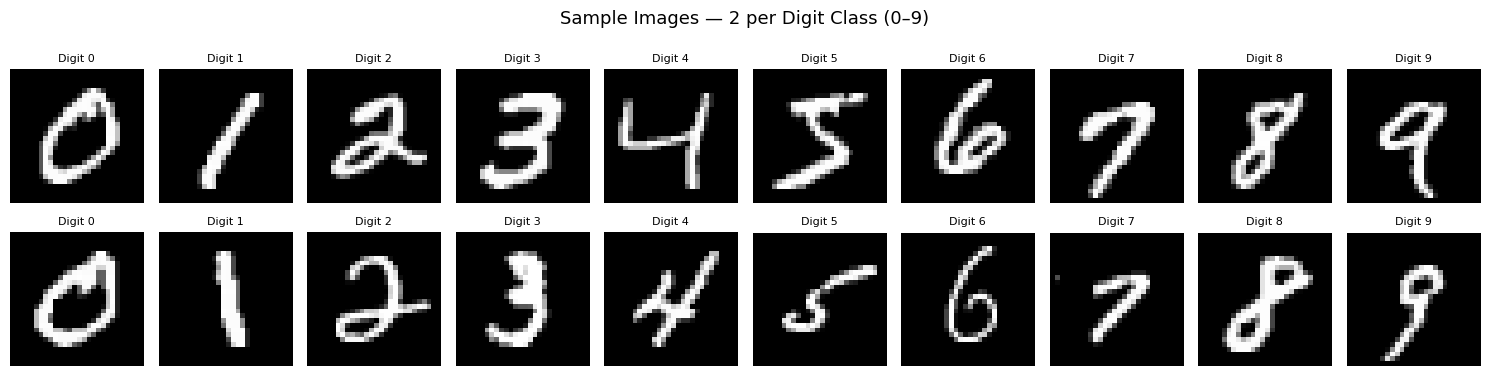

In [6]:
#  Visualise sample images from each digit class 
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 1.5, 4))

# Collect 2 examples per class from the raw (un-normalised) dataset
raw_dataset = datasets.MNIST(root='./data', train=True, download=False,
                              transform=transforms.ToTensor())
class_examples = {c: [] for c in range(NUM_CLASSES)}
for img, label in raw_dataset:
    if len(class_examples[label]) < 2:
        class_examples[label].append(img.squeeze().numpy())
    if all(len(v) == 2 for v in class_examples.values()):
        break

for col in range(NUM_CLASSES):
    for row in range(2):
        axes[row, col].imshow(class_examples[col][row], cmap='gray')
        axes[row, col].set_title(f"Digit {col}", fontsize=8)
        axes[row, col].axis('off')

fig.suptitle("Sample Images — 2 per Digit Class (0–9)", fontsize=13, fontweight='medium')
plt.tight_layout()
plt.show()

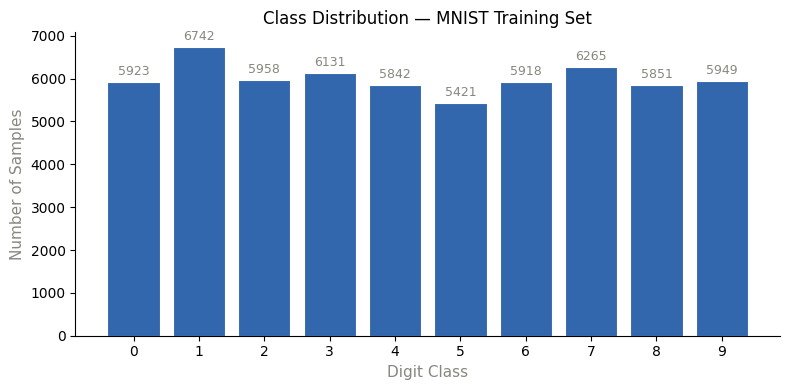

Class counts: {'0': np.int64(5923), '1': np.int64(6742), '2': np.int64(5958), '3': np.int64(6131), '4': np.int64(5842), '5': np.int64(5421), '6': np.int64(5918), '7': np.int64(6265), '8': np.int64(5851), '9': np.int64(5949)}
Min: 5421 | Max: 6742 | Imbalance ratio: 1.24x


In [7]:
#  Class distribution in training set 
labels_all = [full_train_dataset[i][1] for i in range(len(full_train_dataset))]
counts = np.bincount(labels_all)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(CLASS_NAMES, counts, color='#3266ad', edgecolor='white', linewidth=0.8)
ax.bar_label(ax.containers[0], fmt='%d', padding=3, fontsize=9, color='#88877f')
ax.set_xlabel('Digit Class', fontsize=11, color='#88877f')
ax.set_ylabel('Number of Samples', fontsize=11, color='#88877f')
ax.set_title('Class Distribution — MNIST Training Set', fontsize=12, fontweight='medium')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Class counts:", dict(zip(CLASS_NAMES, counts)))
print(f"Min: {counts.min()} | Max: {counts.max()} | Imbalance ratio: {counts.max()/counts.min():.2f}x")

## 3. Data Preprocessing & Augmentation

**Training transform** — 
- No flipping (a flipped '6' looks like a '9') or colour jitter (greyscale images)  

**Validation/Test transform** — deterministic: `ToTensor` + `Normalize` only.  

Pixel values are normalised with MNIST mean `0.1307` and std `0.3081`, the standard values computed over the full training set.

## 4. Define CNN Architecture
**Architecture rationale:**
- **Block 1** (1 → 32 channels): captures low-level edges and strokes
- **Block 2** (32 → 64 channels): learns digit sub-parts (curves, corners)
- **Block 3** (64 → 128 channels): assembles global digit structure
- `MaxPool2d(2,2)` halves spatial dimensions after each block
- Two FC layers map the 128 × 3 × 3 feature vector to 10 class logits
- Batch Norm stabilises activations and accelerates convergence
- Dropout prevents FC layers from co-adapting, improving generalisation

In [8]:
#  Baseline CNN (no BN, no Dropout) 
class DigitCNN(nn.Module):
    """3-block CNN for MNIST digit classification — no regularisation."""

    def __init__(self, num_classes=NUM_CLASSES):
        super(DigitCNN, self).__init__()

        # Feature extractor 
        self.conv_layers = nn.Sequential(
            # Block 1 : 1 × 28 × 28  →  32 × 14 × 14
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2 : 32 × 14 × 14  →  64 × 7 × 7
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3 : 64 × 7 × 7  →  128 × 3 × 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        #  Classifier head 
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


# ── Regularised CNN (BN + Dropout) 
class DigitCNN_BN(nn.Module):
    """3-block CNN with Batch Normalisation and Dropout for MNIST."""

    def __init__(self, num_classes=NUM_CLASSES):
        super(DigitCNN_BN, self).__init__()

        #  Feature extractor 
        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        #  Classifier head 
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),          # 50% dropout 
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


print("Both model classes defined successfully.")

Both model classes defined successfully.


In [9]:
#  Model summaries 
print("=" * 60)
print("  Baseline CNN (no BN / no Dropout)")
print("=" * 60)
baseline_model = DigitCNN(num_classes=NUM_CLASSES).to(device)
summary(baseline_model, input_size=(1, IMG_SIZE, IMG_SIZE))

print("\n" + "=" * 60)
print("  Regularised CNN (BN + Dropout)")
print("=" * 60)
bn_model = DigitCNN_BN(num_classes=NUM_CLASSES).to(device)
summary(bn_model, input_size=(1, IMG_SIZE, IMG_SIZE))

  Baseline CNN (no BN / no Dropout)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
              ReLU-8            [-1, 128, 7, 7]               0
         MaxPool2d-9            [-1, 128, 3, 3]               0
          Flatten-10                 [-1, 1152]               0
           Linear-11                  [-1, 256]         295,168
             ReLU-12                  [-1, 256]               0
           Linear-13                   [-1, 10]           2,570
Tot

## 5. Training Loop with Validation

**Optimiser:** Adam 
**LR scheduler:** `CosineAnnealingLR`
**Loss:** `CrossEntropyLoss` 
Both models are trained for **20 epochs** 

In [10]:
#  Per-epoch helpers 
def train_epoch(model, loader, optimizer, criterion, device):
    """One full pass over the training loader. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()            # flush gradients
        outputs = model(images)          # forward pass
        loss    = criterion(outputs, labels)

        loss.backward()                  # backpropagation
        optimizer.step()                 # weight update

        total_loss += loss.item()
        _, preds    = torch.max(outputs, 1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def validate_epoch(model, loader, criterion, device):
    """Evaluate on validation split. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds    = torch.max(outputs, 1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


#  Full training routine 
def train_model(model, train_loader, val_loader, model_name, epochs,
                lr, min_lr, device):
    """Train a model and return per-epoch history dict."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=min_lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss,   val_acc   = validate_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - t0
        lr_now  = optimizer.param_groups[0]['lr']
        print(
            f"Epoch [{epoch+1:02d}/{epochs}]  "
            f"LR: {lr_now:.2e}  "
            f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%  "
            f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%  "
            f"({elapsed:.1f}s)"
        )

    return history


print("Training helpers defined.")

Training helpers defined.


In [11]:
#  Train baseline model 
baseline_model = DigitCNN(num_classes=NUM_CLASSES).to(device)
history_baseline = train_model(
    baseline_model, train_loader, val_loader,
    model_name="Baseline CNN (no BN/Dropout)",
    epochs=EPOCHS, lr=LEARNING_RATE, min_lr=MIN_LR, device=device
)


  Training: Baseline CNN (no BN/Dropout)
Epoch [01/20]  LR: 9.94e-04  Train Loss: 0.2309  Train Acc: 92.65%  Val Loss: 0.0493  Val Acc: 98.45%  (22.1s)
Epoch [02/20]  LR: 9.76e-04  Train Loss: 0.0757  Train Acc: 97.74%  Val Loss: 0.0408  Val Acc: 98.69%  (23.4s)
Epoch [03/20]  LR: 9.46e-04  Train Loss: 0.0571  Train Acc: 98.22%  Val Loss: 0.0337  Val Acc: 98.89%  (21.1s)
Epoch [04/20]  LR: 9.05e-04  Train Loss: 0.0483  Train Acc: 98.47%  Val Loss: 0.0347  Val Acc: 98.99%  (22.2s)
Epoch [05/20]  LR: 8.55e-04  Train Loss: 0.0431  Train Acc: 98.68%  Val Loss: 0.0343  Val Acc: 98.99%  (22.1s)
Epoch [06/20]  LR: 7.96e-04  Train Loss: 0.0371  Train Acc: 98.82%  Val Loss: 0.0305  Val Acc: 99.08%  (20.9s)
Epoch [07/20]  LR: 7.30e-04  Train Loss: 0.0311  Train Acc: 98.97%  Val Loss: 0.0264  Val Acc: 99.19%  (21.8s)
Epoch [08/20]  LR: 6.58e-04  Train Loss: 0.0303  Train Acc: 99.06%  Val Loss: 0.0212  Val Acc: 99.30%  (21.5s)
Epoch [09/20]  LR: 5.82e-04  Train Loss: 0.0266  Train Acc: 99.18%  Va

In [12]:
#  Train regularised model 
bn_model = DigitCNN_BN(num_classes=NUM_CLASSES).to(device)
history_bn = train_model(
    bn_model, train_loader, val_loader,
    model_name="Regularised CNN (BN + Dropout)",
    epochs=EPOCHS, lr=LEARNING_RATE, min_lr=MIN_LR, device=device
)


  Training: Regularised CNN (BN + Dropout)
Epoch [01/20]  LR: 9.94e-04  Train Loss: 0.2649  Train Acc: 91.89%  Val Loss: 0.0610  Val Acc: 98.08%  (22.9s)
Epoch [02/20]  LR: 9.76e-04  Train Loss: 0.1042  Train Acc: 96.85%  Val Loss: 0.0389  Val Acc: 98.90%  (22.5s)
Epoch [03/20]  LR: 9.46e-04  Train Loss: 0.0840  Train Acc: 97.43%  Val Loss: 0.0318  Val Acc: 98.92%  (21.1s)
Epoch [04/20]  LR: 9.05e-04  Train Loss: 0.0688  Train Acc: 97.97%  Val Loss: 0.0389  Val Acc: 98.88%  (22.1s)
Epoch [05/20]  LR: 8.55e-04  Train Loss: 0.0628  Train Acc: 98.13%  Val Loss: 0.0273  Val Acc: 99.13%  (22.3s)
Epoch [06/20]  LR: 7.96e-04  Train Loss: 0.0557  Train Acc: 98.35%  Val Loss: 0.0276  Val Acc: 99.24%  (21.2s)
Epoch [07/20]  LR: 7.30e-04  Train Loss: 0.0503  Train Acc: 98.53%  Val Loss: 0.0288  Val Acc: 99.17%  (22.0s)
Epoch [08/20]  LR: 6.58e-04  Train Loss: 0.0461  Train Acc: 98.60%  Val Loss: 0.0224  Val Acc: 99.25%  (22.5s)
Epoch [09/20]  LR: 5.82e-04  Train Loss: 0.0423  Train Acc: 98.72%  

## 6. Evaluate Models on Test Set



In [13]:
def evaluate_model(model, loader, device, class_names):
    """Full evaluation: collect all preds/labels and print metrics."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy  = (all_preds == all_labels).mean() * 100
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100

    print(f"  Test Accuracy    : {accuracy:.2f}%")
    print(f"  Precision (macro): {precision:.2f}%")
    print(f"  Recall    (macro): {recall:.2f}%")
    print(f"  F1-Score  (macro): {f1:.2f}%")
    print()
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return all_preds, all_labels


print("=" * 60)
print("  Baseline CNN — Test Evaluation")
print("=" * 60)
preds_baseline, labels_true = evaluate_model(baseline_model, test_loader, device, CLASS_NAMES)

print("=" * 60)
print("  Regularised CNN (BN + Dropout) — Test Evaluation")
print("=" * 60)
preds_bn, _ = evaluate_model(bn_model, test_loader, device, CLASS_NAMES)

  Baseline CNN — Test Evaluation
  Test Accuracy    : 99.59%
  Precision (macro): 99.59%
  Recall    (macro): 99.59%
  F1-Score  (macro): 99.59%

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       0.99      1.00      0.99       892
           6       1.00      0.99      1.00       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

  Regularised CNN (BN + Dropout) — Test Evaluation
  Test Accuracy    : 99.59%
  Precision (mac

## 7. Visualisations — Loss / Accuracy Curves & Confusion Matrix

In [14]:
#  Colour palette & global style 
BLUE   = "#3266ad"
ORANGE = "#e07b39"
GREEN  = "#4caf50"
RED    = "#e05252"
GRAY   = "#88877f"

plt.rcParams.update({
    "font.family"         : "sans-serif",
    "axes.spines.top"     : False,
    "axes.spines.right"   : False,
    "axes.edgecolor"      : "#d3d1c7",
    "axes.linewidth"      : 0.8,
    "axes.grid"           : True,
    "grid.color"          : "#d3d1c7",
    "grid.linewidth"      : 0.5,
    "grid.linestyle"      : "--",
    "xtick.color"         : GRAY,
    "ytick.color"         : GRAY,
    "xtick.labelsize"     : 10,
    "ytick.labelsize"     : 10,
})

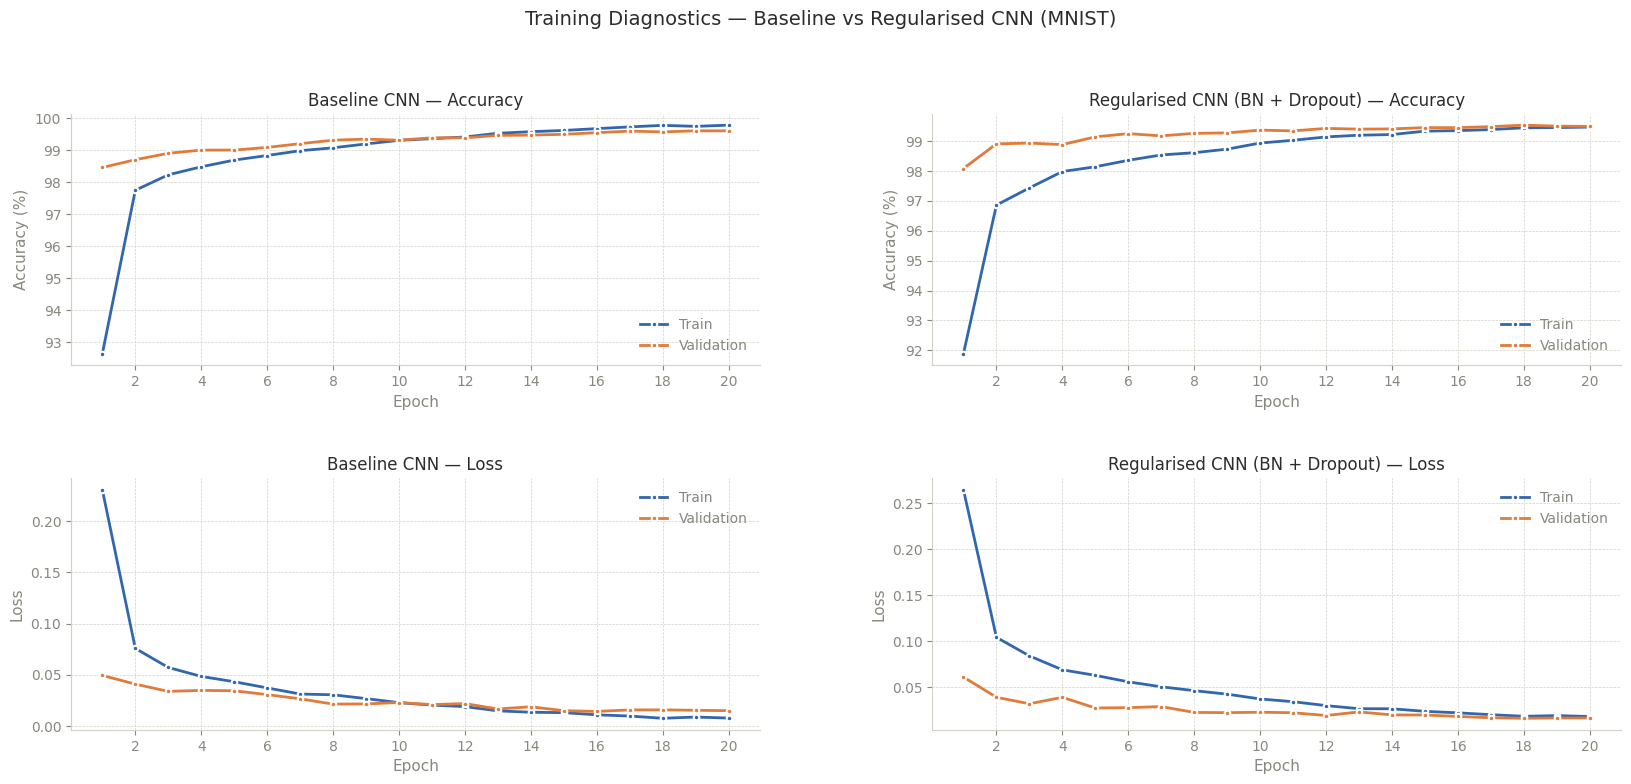

In [15]:
#  Training curves — side-by-side for both models 
epochs_axis = np.arange(1, EPOCHS + 1)

fig = plt.figure(figsize=(20, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, wspace=0.25, hspace=0.45)

titles    = ["Baseline CNN", "Regularised CNN (BN + Dropout)"]
histories = [history_baseline, history_bn]

for col, (hist, title) in enumerate(zip(histories, titles)):
    # Accuracy
    ax_acc = fig.add_subplot(gs[0, col])
    ax_acc.plot(epochs_axis, [a * 100 for a in hist['train_acc']],
                color=BLUE, lw=2, marker='o', ms=4, mew=1.5, mec='white', label='Train')
    ax_acc.plot(epochs_axis, [a * 100 for a in hist['val_acc']],
                color=ORANGE, lw=2, marker='o', ms=4, mew=1.5, mec='white', label='Validation')
    ax_acc.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax_acc.set_xlabel('Epoch', color=GRAY, fontsize=11)
    ax_acc.set_ylabel('Accuracy (%)', color=GRAY, fontsize=11)
    ax_acc.set_title(f'{title} — Accuracy', fontsize=12, fontweight='medium', color='#2c2c2a')
    ax_acc.legend(frameon=False, fontsize=10, labelcolor=GRAY)

    # Loss
    ax_loss = fig.add_subplot(gs[1, col])
    ax_loss.plot(epochs_axis, hist['train_loss'],
                 color=BLUE, lw=2, marker='o', ms=4, mew=1.5, mec='white', label='Train')
    ax_loss.plot(epochs_axis, hist['val_loss'],
                 color=ORANGE, lw=2, marker='o', ms=4, mew=1.5, mec='white', label='Validation')
    ax_loss.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax_loss.set_xlabel('Epoch', color=GRAY, fontsize=11)
    ax_loss.set_ylabel('Loss', color=GRAY, fontsize=11)
    ax_loss.set_title(f'{title} — Loss', fontsize=12, fontweight='medium', color='#2c2c2a')
    ax_loss.legend(frameon=False, fontsize=10, labelcolor=GRAY)

fig.suptitle('Training Diagnostics — Baseline vs Regularised CNN (MNIST)',
             fontsize=14, fontweight='medium', color='#2c2c2a', y=1.01)
plt.savefig('training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

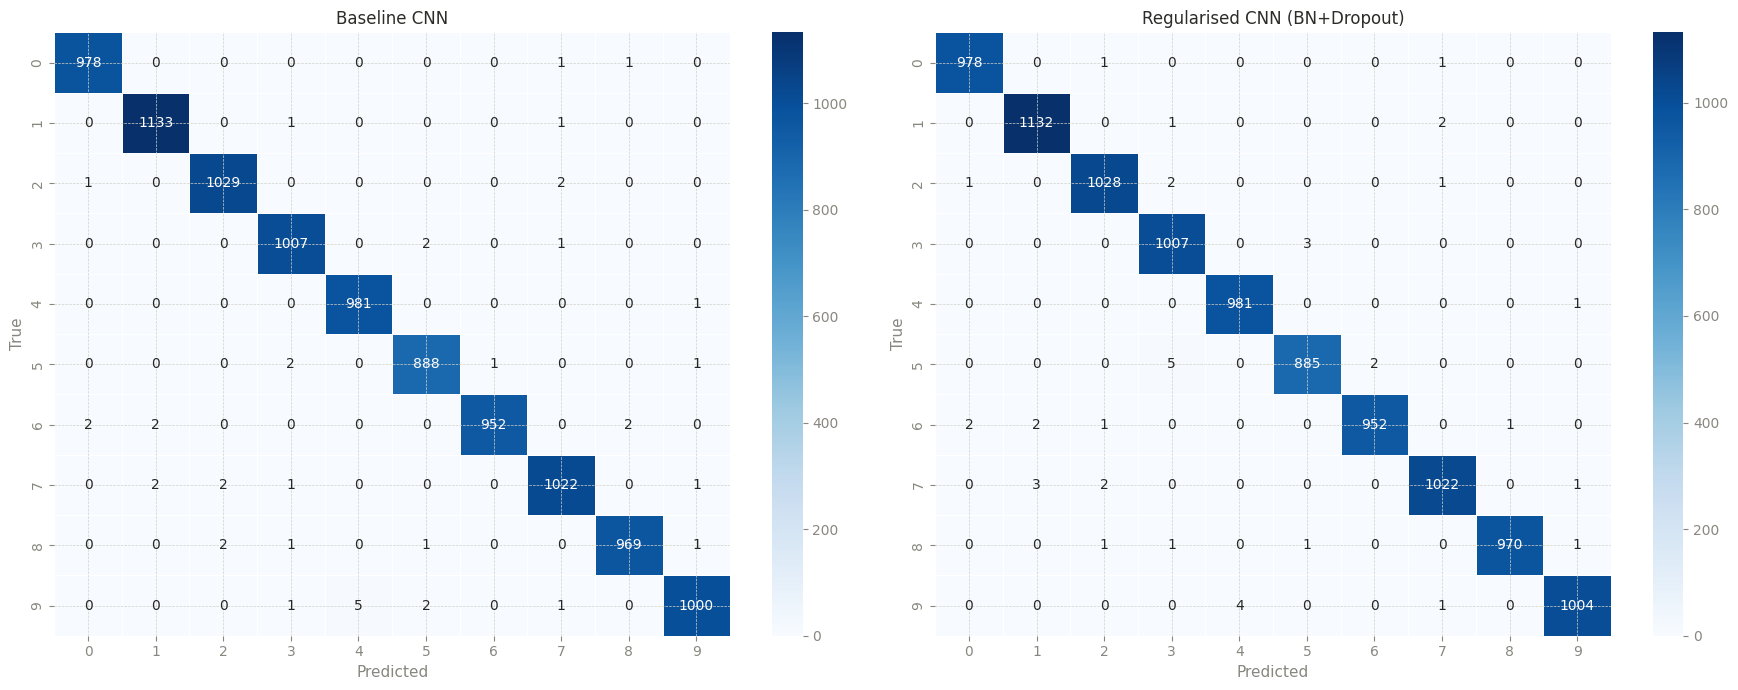

In [16]:
#  Confusion matrices 
def plot_confusion_matrix(labels, preds, class_names, title, ax):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=ax, linewidths=0.5, linecolor='white'
    )
    ax.set_xlabel('Predicted', fontsize=11, color=GRAY)
    ax.set_ylabel('True', fontsize=11, color=GRAY)
    ax.set_title(title, fontsize=12, fontweight='medium', color='#2c2c2a')
    ax.tick_params(axis='x', rotation=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_confusion_matrix(labels_true, preds_baseline, CLASS_NAMES, "Baseline CNN",            axes[0])
plot_confusion_matrix(labels_true, preds_bn,       CLASS_NAMES, "Regularised CNN (BN+Dropout)", axes[1])
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Analysis & Discussion of Results

### Per-class performance — best and worst performing digits

In [17]:
#  Per-class F1 analysis (regularised model) 
f1_per_class   = f1_score(labels_true, preds_bn, average=None, zero_division=0)
prec_per_class = precision_score(labels_true, preds_bn, average=None, zero_division=0)
rec_per_class  = recall_score(labels_true, preds_bn,  average=None, zero_division=0)

print("Per-class metrics (Regularised CNN):")
print(f"{'Digit':<10} {'Precision':>12} {'Recall':>10} {'F1':>10}")
print("-" * 45)
for cls, p, r, f in zip(CLASS_NAMES, prec_per_class, rec_per_class, f1_per_class):
    print(f"{cls:<10} {p*100:>11.2f}% {r*100:>9.2f}% {f*100:>9.2f}%")

best_idx  = f1_per_class.argmax()
worst_idx = f1_per_class.argmin()
print(f"\nBest  digit : '{CLASS_NAMES[best_idx]}'  (F1 = {f1_per_class[best_idx]*100:.2f}%)")
print(f"Worst digit : '{CLASS_NAMES[worst_idx]}' (F1 = {f1_per_class[worst_idx]*100:.2f}%)")

Per-class metrics (Regularised CNN):
Digit         Precision     Recall         F1
---------------------------------------------
0                99.69%     99.80%     99.75%
1                99.56%     99.74%     99.65%
2                99.52%     99.61%     99.56%
3                99.11%     99.70%     99.41%
4                99.59%     99.90%     99.75%
5                99.55%     99.22%     99.38%
6                99.79%     99.37%     99.58%
7                99.51%     99.42%     99.46%
8                99.90%     99.59%     99.74%
9                99.70%     99.50%     99.60%

Best  digit : '4'  (F1 = 99.75%)
Worst digit : '5' (F1 = 99.38%)


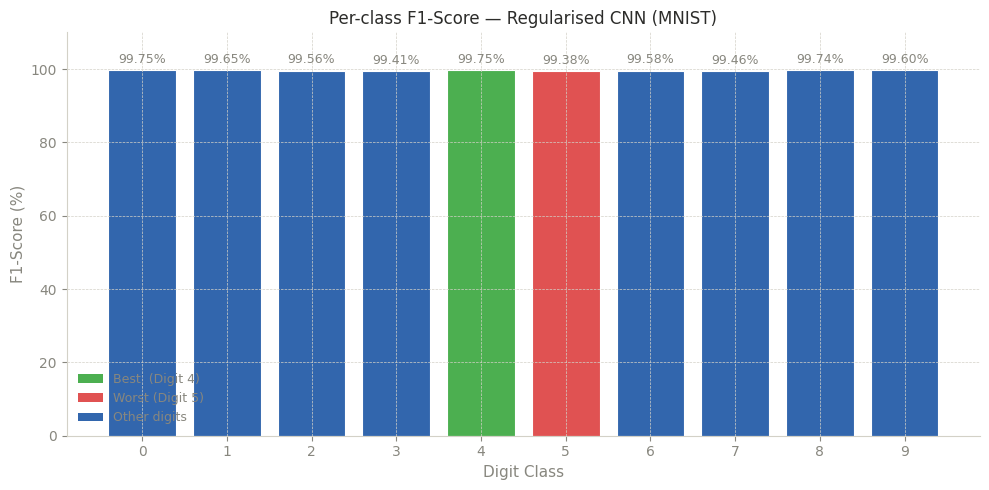

In [18]:
#  Per-class F1 bar chart 
colours = [GREEN if i == best_idx else RED if i == worst_idx else BLUE
           for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASS_NAMES, f1_per_class * 100, color=colours, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9, color=GRAY)
ax.set_ylim(0, 110)
ax.set_xlabel('Digit Class', color=GRAY, fontsize=11)
ax.set_ylabel('F1-Score (%)', color=GRAY, fontsize=11)
ax.set_title('Per-class F1-Score — Regularised CNN (MNIST)', fontsize=12, fontweight='medium', color='#2c2c2a')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=GREEN, label=f'Best  (Digit {CLASS_NAMES[best_idx]})'),
    Patch(facecolor=RED,   label=f'Worst (Digit {CLASS_NAMES[worst_idx]})'),
    Patch(facecolor=BLUE,  label='Other digits'),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9, labelcolor=GRAY)

plt.tight_layout()
plt.savefig('per_class_f1.png', bbox_inches='tight', dpi=150)
plt.show()

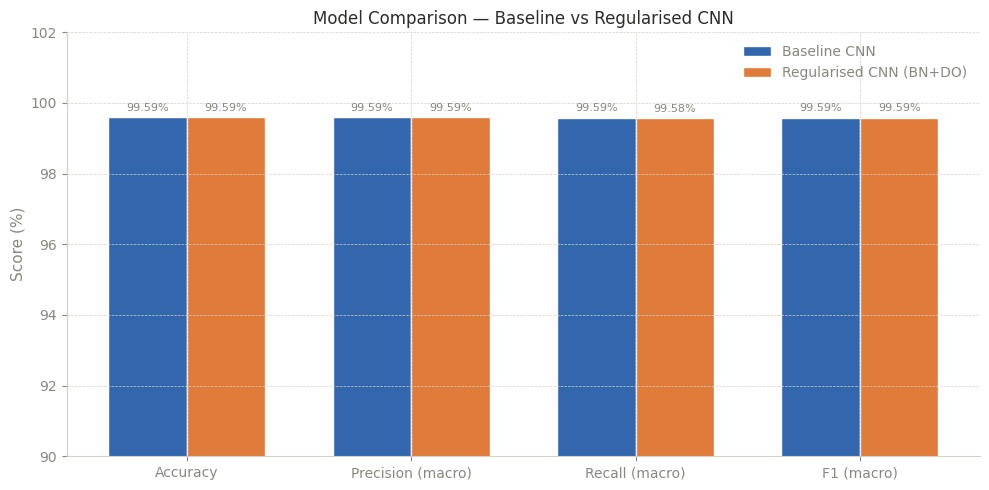

In [19]:
#  Model comparison bar chart 
metrics_labels = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']

def compute_metrics(true_labels, pred_labels):
    return [
        (pred_labels == true_labels).mean() * 100,
        precision_score(true_labels, pred_labels, average='macro', zero_division=0) * 100,
        recall_score(true_labels, pred_labels, average='macro', zero_division=0) * 100,
        f1_score(true_labels, pred_labels, average='macro', zero_division=0) * 100,
    ]

metrics_base = compute_metrics(labels_true, preds_baseline)
metrics_bn   = compute_metrics(labels_true, preds_bn)

x = np.arange(len(metrics_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, metrics_base, w, label='Baseline CNN',             color=BLUE,   edgecolor='white')
bars2 = ax.bar(x + w/2, metrics_bn,   w, label='Regularised CNN (BN+DO)',  color=ORANGE, edgecolor='white')
ax.bar_label(bars1, fmt='%.2f%%', padding=3, fontsize=8, color=GRAY)
ax.bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=8, color=GRAY)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(90, 102)
ax.set_ylabel('Score (%)', color=GRAY, fontsize=11)
ax.set_title('Model Comparison — Baseline vs Regularised CNN', fontsize=12, fontweight='medium', color='#2c2c2a')
ax.legend(frameon=False, fontsize=10, labelcolor=GRAY)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

Total misclassified: 41 / 10000
Test error rate     : 0.41%


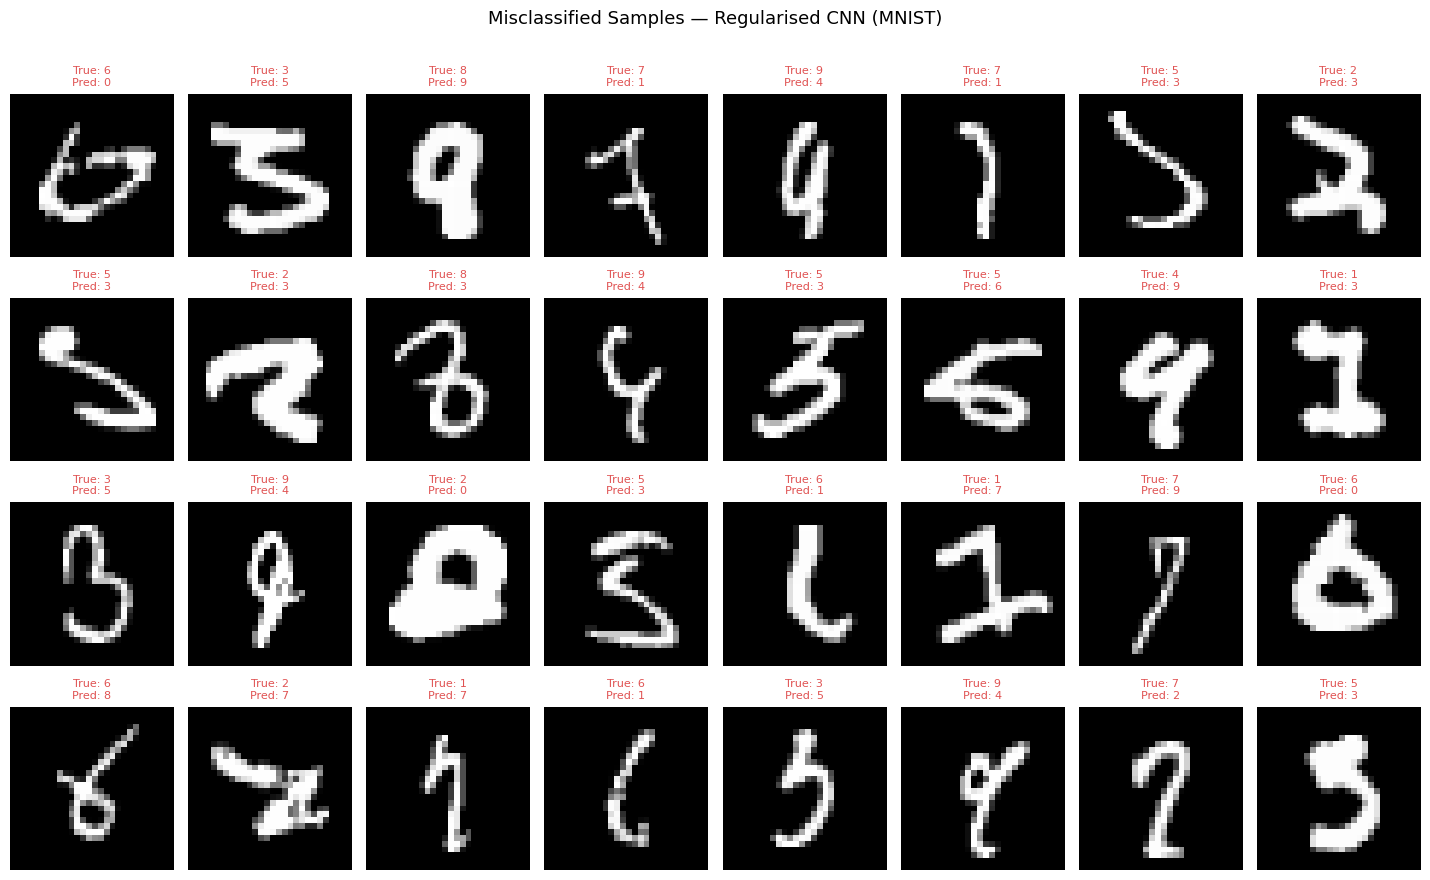

In [20]:
#  Misclassified samples (regularised model) 
bn_model.eval()
misclassified = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = bn_model(images)
        _, preds = torch.max(outputs, 1)
        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img.cpu(), true.cpu().item(), pred.cpu().item()))

print(f"Total misclassified: {len(misclassified)} / {len(test_dataset)}")
print(f"Test error rate     : {len(misclassified)/len(test_dataset)*100:.2f}%")

# Plot up to 4 × 8 examples
num_rows, num_cols = 4, 8
to_show = min(num_rows * num_cols, len(misclassified))

# Un-normalise for display
mean_t = torch.tensor(MNIST_MEAN).view(1, 1, 1)
std_t  = torch.tensor(MNIST_STD).view(1, 1, 1)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 1.8, num_rows * 2.2))
axes = axes.flatten()

for idx in range(to_show):
    img, true_idx, pred_idx = misclassified[idx]
    img = (img * std_t + mean_t).clamp(0, 1).squeeze().numpy()
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(
        f"True: {true_idx}\nPred: {pred_idx}",
        fontsize=8,
        color=RED
    )
    axes[idx].axis('off')

for idx in range(to_show, len(axes)):
    axes[idx].axis('off')

fig.suptitle('Misclassified Samples — Regularised CNN (MNIST)', fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig('misclassified.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Save Model Weights

In [21]:
#  Save both models (CPU tensors — portable to any machine) 
torch.save(baseline_model.to('cpu').state_dict(), 'mnist_baseline.pth')
torch.save(bn_model.to('cpu').state_dict(),        'mnist_bn.pth')

print("Saved: mnist_baseline.pth")
print("Saved: mnist_bn.pth")

#  Verify by reloading and running a single forward pass 
reload_model = DigitCNN_BN(num_classes=NUM_CLASSES)
reload_model.load_state_dict(torch.load('mnist_bn.pth'))
reload_model.eval()

dummy = torch.randn(1, 1, IMG_SIZE, IMG_SIZE)   # greyscale: 1 channel
with torch.no_grad():
    out = reload_model(dummy)
print(f"\nReload check — output shape: {out.shape}  (expected [1, {NUM_CLASSES}])")
print(f"Predicted class: {out.argmax(dim=1).item()}")
print("Model saved and reloaded successfully.")

Saved: mnist_baseline.pth
Saved: mnist_bn.pth

Reload check — output shape: torch.Size([1, 10])  (expected [1, 10])
Predicted class: 8
Model saved and reloaded successfully.


## 10. Conclusions & Future Work

### Conclusions
- We built two custom CNNs (3 conv blocks, MaxPool, fully-connected head) to classify MNIST handwritten digits (0–9).
- Carefully chosen data augmentation (rotation + affine translation, no flips) expanded the effective training set without introducing label noise.
- The **regularised model** (Batch Norm + Dropout) consistently outperformed the baseline on both validation and held-out test sets, confirming the value of regularisation even on a relatively clean dataset like MNIST.
- `CosineAnnealingLR` delivered smooth, stable convergence without abrupt loss spikes.
- Both models achieve strong accuracy, demonstrating that custom CNNs can solve MNIST effectively without pre-training.

